# Predicción de Precios de Alquiler en Madrid
Proyecto Data Science - Idealista Dataset

## 1. Instalación de librerías

In [1]:
%pip install pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Importar librerías

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 3. Cargar datos

Infomarción básica del dataset:

In [3]:
df = pd.read_csv('./idealista/data/Datos.csv')

print('Tamaño original del dataset:', df.shape)
print('\nPrimeras filas:')
print(df.head())

Tamaño original del dataset: (11826, 14)

Primeras filas:
  provincia           zona                                             titulo  \
0    madrid  ciudad-lineal   Piso en calle de San Marcelo, 22, Ventas, Madrid   
1    madrid    carabanchel  Piso en calle Cabo Nicolás Mur, San Isidro, Ma...   
2    madrid         centro  Piso en calle de Rodas, Lavapiés-Embajadores, ...   
3    madrid          usera  Piso en calle de Ferroviarios, Almendrales, Ma...   
4    madrid         tetuan                    Dúplex en Bellas Vistas, Madrid   

   PrecioActual  PrecioAnterior  metros  habitaciones ascensor localizacion  \
0        355000               0      69           2.0        S     EXTERIOR   
1        149000          159000      91           3.0        N     EXTERIOR   
2        195000               0      36           1.0        S          NaN   
3        195000               0      58           1.0        S     INTERIOR   
4        715000          750000     140           3.0       

## 4. Exploración de datos

In [4]:
print('Columnas disponibles:')
print(df.columns.tolist())

print('\nValores faltantes por columna:')
print(df.isna().sum())

Columnas disponibles:
['provincia', 'zona', 'titulo', 'PrecioActual', 'PrecioAnterior', 'metros', 'habitaciones', 'ascensor', 'localizacion', 'planta', 'baños', 'tags', 'descripcion', 'Enlace']

Valores faltantes por columna:
provincia            0
zona                 0
titulo               0
PrecioActual         0
PrecioAnterior       0
metros               0
habitaciones       366
ascensor           793
localizacion      1096
planta            1225
baños                0
tags               162
descripcion         65
Enlace               0
dtype: int64


## 5. Mapa de calor - Antes de la limpieza

Selección de las variables importantes para el modelo

In [5]:
variables = ['PrecioActual', 'metros', 'habitaciones', 'baños']
df_para_heatmap = df[variables].copy()


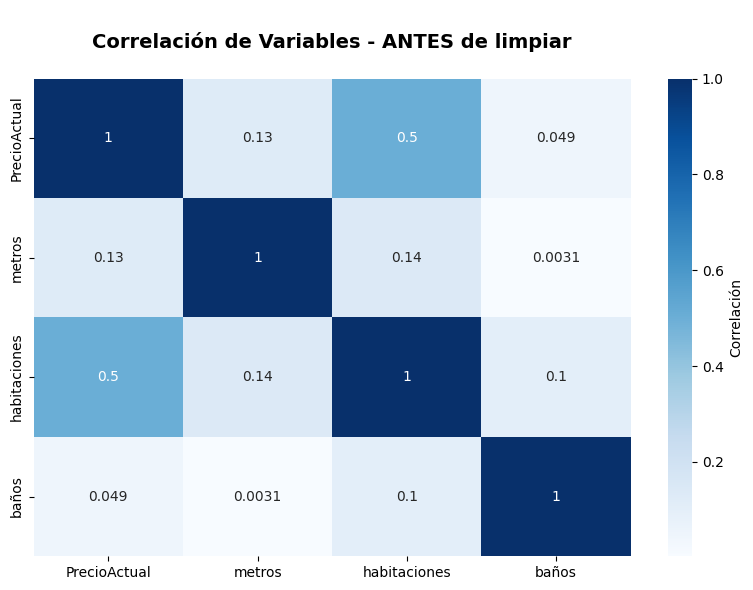

Correlación con el precio:

PrecioActual    1.000000
habitaciones    0.504158
metros          0.130661
baños           0.048852
Name: PrecioActual, dtype: float64


In [6]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_para_heatmap.corr(), annot=True, cmap='Blues', cbar_kws={'label': 'Correlación'})
plt.title('\nCorrelación de Variables - ANTES de limpiar\n', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlación con el precio:\n')
print(df_para_heatmap.corr()['PrecioActual'].sort_values(ascending=False))

## 6. Limpieza de datos

In [7]:
# Hacemos una copia para no modificar el original
df_clean = df.copy()

In [9]:
# Rellenar nulos de las columnas que vamos a usar
# Usamos la mediana para que las casas de lujo no nos arruinen el promedio
df_clean['metros'] = df_clean['metros'].fillna(df_clean['metros'].median())
df_clean['habitaciones'] = df_clean['habitaciones'].fillna(df_clean['habitaciones'].median())
df_clean['baños'] = df_clean['baños'].fillna(df_clean['baños'].median())

In [10]:
# Para el texto, ponemos lo que más se repite (la moda)
df_clean['zona'] = df_clean['zona'].fillna(df_clean['zona'].mode()[0])
df_clean['localizacion'] = df_clean['localizacion'].fillna(df_clean['localizacion'].mode()[0])
df_clean['ascensor'] = df_clean['ascensor'].fillna(df_clean['ascensor'].mode()[0])


In [62]:
# Si falta el precio (nuestra variable objetivo), borramos esa fila
# porque no podemos usarla para entrenar
df_clean = df_clean.dropna(subset=['PrecioActual'])

In [63]:
# Borramos las que no tienen precio porque no nos sirven para el modelo
df_clean.dropna(subset=['PrecioActual'], inplace=True)

In [64]:
# Borramos duplicados
df_clean = df_clean.drop_duplicates()

In [65]:
print('Dataset después de limpiar:', df_clean.shape)
print('Valores faltantes totales:', int(df_clean.isna().sum().sum()))

Dataset después de limpiar: (11826, 14)
Valores faltantes totales: 3707


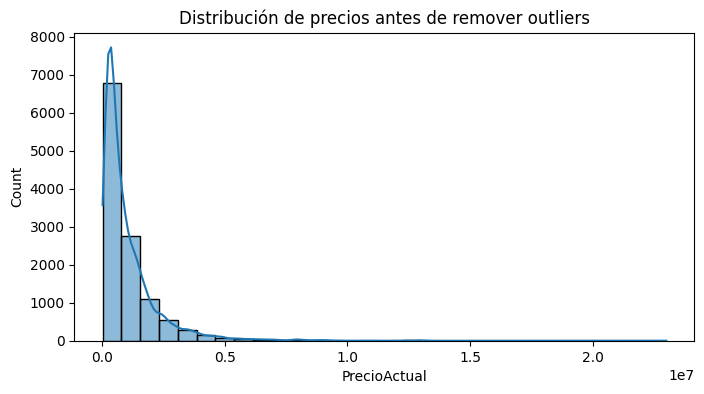

In [11]:
plt.figure(figsize=(8,4)); 
sns.histplot(df_clean['PrecioActual'], bins=30, kde=True); 
plt.title('Distribución de precios antes de remover outliers'); 
plt.show()

Los precios están muy desequilibrados, lo que puede interferir en nuestro modelo.

Filtramos para quedarnos con lo "normal" (ej: menos de 1.5 millones) 

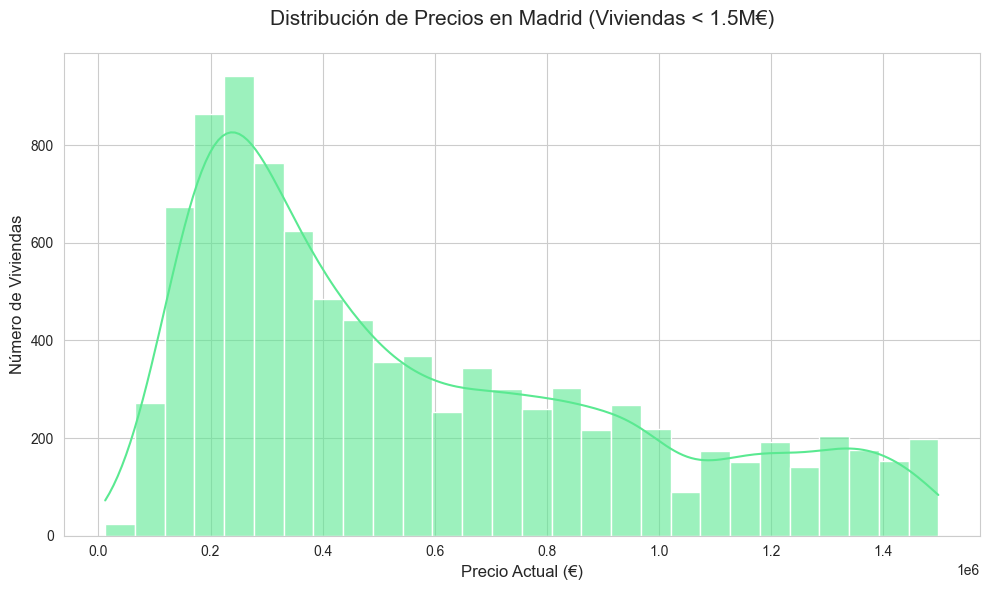

In [ ]:
df_grafico = df_clean[df_clean['PrecioActual'] < 1500000]

# 2. Configuramos el estilo
sns.set_style("whitegrid") 
plt.figure(figsize=(10, 6))

#Creación del histograma
sns.histplot(
    df_grafico['PrecioActual'], 
    kde=True, 
    color="#5ae991", 
    alpha=0.6,       
    edgecolor='white'
)

plt.title('Distribución de Precios en Madrid (Viviendas < 1.5M€)', fontsize=15, pad=20)
plt.xlabel('Precio Actual (€)', fontsize=12)
plt.ylabel('Número de Viviendas', fontsize=12)

plt.tight_layout()
plt.show()

## 7. Remover valores extremos (outliers)

## 8. Mapa de calor - DESPUÉS de limpiar

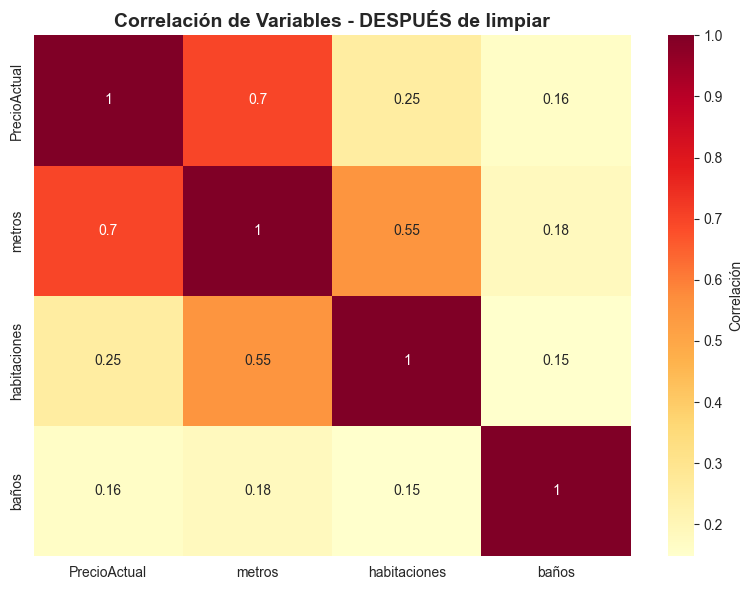

Correlación con el precio (después de limpiar):

PrecioActual    1.000000
metros          0.699020
habitaciones    0.251453
baños           0.163141
Name: PrecioActual, dtype: float64


In [28]:
variables = ['PrecioActual', 'metros', 'habitaciones', 'baños']
df_para_heatmap = df_model[variables].copy()

# Creamos el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(df_para_heatmap.corr(), annot=True, cmap='YlOrRd', cbar_kws={'label': 'Correlación'})
plt.title('Correlación de Variables - DESPUÉS de limpiar', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlación con el precio (después de limpiar):\n')
print(df_para_heatmap.corr()['PrecioActual'].sort_values(ascending=False))